# CCT College Dublin
## Higher Diploma in Science in Data Analytics for Business

---

| | |
|---|---|
| **Student Name** | Gleiciane Rocha |
| **Module(s)** | Data Preparation / Statistical Techniques for DA / Machine Learning |
| **Assessment** | Integrated CA2 |
| **Dataset** | Irish Coastal Fisheries Performance Data |
| **Lecturer(s)** | David McQuaid / Sam Weiss / Muhammad Iqbal |
| **Submission Date** | 29th May 2026 |

---

## Project Overview

# Integrated CA2 — Fisheries Performance Analysis

This notebook contains the full analysis of a fisheries performance dataset collected across different Irish coastal counties. The dataset includes economic, environmental, operational, and sustainability-related indicators connected to the Irish fishing industry.

The main aim of this project is to explore the factors that influence fisheries performance, analyse export demand levels, and predict annual fisheries revenue using data analytics, statistics, and machine learning techniques.

The analysis is organised into three main sections:

- **Part 1 — Data Preparation:** Dataset characterisation, data cleaning, exploratory data analysis (EDA), encoding, scaling, feature engineering, and dimensionality reduction using PCA and LDA.

- **Part 2 — Statistical Techniques for Data Analytics:** Descriptive statistics, probability distributions, confidence intervals, hypothesis testing, correlation analysis, and linear regression.

- **Part 3 — Machine Learning:** Supervised and unsupervised learning, feature selection, hyperparameter tuning, cross-validation, and model comparison.

---

# Part 1 — Data Preparation

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_excel("Fisheries_CA2_Dataset (1).xlsx")

In [9]:
df.head()

,County,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Export_Demand_Level,Vessel_Type,Sustainability_Score,Predicted_Annual_Revenue_EUR
0,Waterford,81077.05,91.19,6.95,5.10,7.10,1.23,4.12,108112.88,High,Longliner,99.44,201495.28
1,Clare,76078.84,99.09,7.51,8.20,6.16,5.38,4.06,112746.74,Average,Trawler,115.02,202484.46
2,Cork,50576.94,91.93,7.59,3.82,4.04,4.71,3.07,132088.49,Low,Longliner,61.75,107997.00
3,Dublin,73236.59,109.53,6.29,7.02,7.60,5.99,5.56,109732.87,Average,Small Boat,115.48,188797.98
4,Dublin,69185.63,109.94,5.41,5.27,8.59,5.38,5.72,91268.62,Average,NaN,110.90,147138.23


In [10]:
df.shape

(2080, 13)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   County                        2059 non-null   object 
 1   Avg_Fisher_Income_EUR         2059 non-null   float64
 2   Fuel_Cost_Index               2059 non-null   float64
 3   Port_Accessibility_Score      2059 non-null   float64
 4   Fish_Stock_Index              2059 non-null   float64
 5   Water_Quality_Score           2059 non-null   float64
 6   Weather_Risk_Index            2059 non-null   float64
 7   Illegal_Fishing_Rate_%        2059 non-null   float64
 8   Aquaculture_Investment_EUR    2059 non-null   float64
 9   Export_Demand_Level           2059 non-null   object 
 10  Vessel_Type                   2059 non-null   object 
 11  Sustainability_Score          2059 non-null   float64
 12  Predicted_Annual_Revenue_EUR  2059 non-null   float64
dtypes: 

In [12]:
df.describe()

,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Sustainability_Score,Predicted_Annual_Revenue_EUR
count,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000
mean,72511.124876,100.088698,5.969354,5.955352,7.006960,4.114594,4.914230,109863.973458,103.040413,174679.905537
std,11845.548793,14.895004,1.980090,1.943586,1.457452,1.896673,2.002769,22225.645739,22.356924,43489.897248
min,35298.260000,52.680000,1.000000,1.000000,2.100000,1.000000,0.000000,38247.500000,25.490000,28148.810000
25%,64806.695000,90.280000,4.620000,4.640000,6.020000,2.695000,3.565000,95427.780000,88.230000,145903.220000
50%,72646.920000,100.280000,6.000000,5.940000,7.030000,4.060000,4.850000,110054.900000,103.500000,176154.600000
75%,80310.940000,109.885000,7.340000,7.260000,8.000000,5.430000,6.305000,125296.360000,118.050000,204900.420000
max,107127.470000,145.030000,10.000000,10.000000,10.000000,10.000000,11.790000,170958.000000,172.740000,303843.800000


## Dataset Characterisation

In [13]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 2080
Number of columns: 13


In [14]:
df.columns

Index(['County', 'Avg_Fisher_Income_EUR', 'Fuel_Cost_Index',
       'Port_Accessibility_Score', 'Fish_Stock_Index', 'Water_Quality_Score',
       'Weather_Risk_Index', 'Illegal_Fishing_Rate_%',
       'Aquaculture_Investment_EUR', 'Export_Demand_Level', 'Vessel_Type',
       'Sustainability_Score', 'Predicted_Annual_Revenue_EUR'],
      dtype='object')

In [15]:
df.dtypes

County                           object
Avg_Fisher_Income_EUR           float64
Fuel_Cost_Index                 float64
Port_Accessibility_Score        float64
Fish_Stock_Index                float64
Water_Quality_Score             float64
Weather_Risk_Index              float64
Illegal_Fishing_Rate_%          float64
Aquaculture_Investment_EUR      float64
Export_Demand_Level              object
Vessel_Type                      object
Sustainability_Score            float64
Predicted_Annual_Revenue_EUR    float64
dtype: object

In [16]:
df.isnull().sum()

County                          21
Avg_Fisher_Income_EUR           21
Fuel_Cost_Index                 21
Port_Accessibility_Score        21
Fish_Stock_Index                21
Water_Quality_Score             21
Weather_Risk_Index              21
Illegal_Fishing_Rate_%          21
Aquaculture_Investment_EUR      21
Export_Demand_Level             21
Vessel_Type                     21
Sustainability_Score            21
Predicted_Annual_Revenue_EUR    21
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

The dataset contains numerical and categorical variables related to fishing performance in Irish coastal counties, after initial verification, missing values were identified in several columns, while no duplicate rows were found in the dataset most variables are numerical, with some categorical variables such as county, export demand level, and vessel type.

In [18]:
missing_values = df.isnull().sum()
missing_values

County                          21
Avg_Fisher_Income_EUR           21
Fuel_Cost_Index                 21
Port_Accessibility_Score        21
Fish_Stock_Index                21
Water_Quality_Score             21
Weather_Risk_Index              21
Illegal_Fishing_Rate_%          21
Aquaculture_Investment_EUR      21
Export_Demand_Level             21
Vessel_Type                     21
Sustainability_Score            21
Predicted_Annual_Revenue_EUR    21
dtype: int64

In [19]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

County                          1.009615
Avg_Fisher_Income_EUR           1.009615
Fuel_Cost_Index                 1.009615
Port_Accessibility_Score        1.009615
Fish_Stock_Index                1.009615
Water_Quality_Score             1.009615
Weather_Risk_Index              1.009615
Illegal_Fishing_Rate_%          1.009615
Aquaculture_Investment_EUR      1.009615
Export_Demand_Level             1.009615
Vessel_Type                     1.009615
Sustainability_Score            1.009615
Predicted_Annual_Revenue_EUR    1.009615
dtype: float64

In [20]:
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_data

,Missing Values,Percentage
County,21,1.009615
Avg_Fisher_Income_EUR,21,1.009615
Fuel_Cost_Index,21,1.009615
Port_Accessibility_Score,21,1.009615
Fish_Stock_Index,21,1.009615
Water_Quality_Score,21,1.009615
Weather_Risk_Index,21,1.009615
Illegal_Fishing_Rate_%,21,1.009615
Aquaculture_Investment_EUR,21,1.009615
Export_Demand_Level,21,1.009615


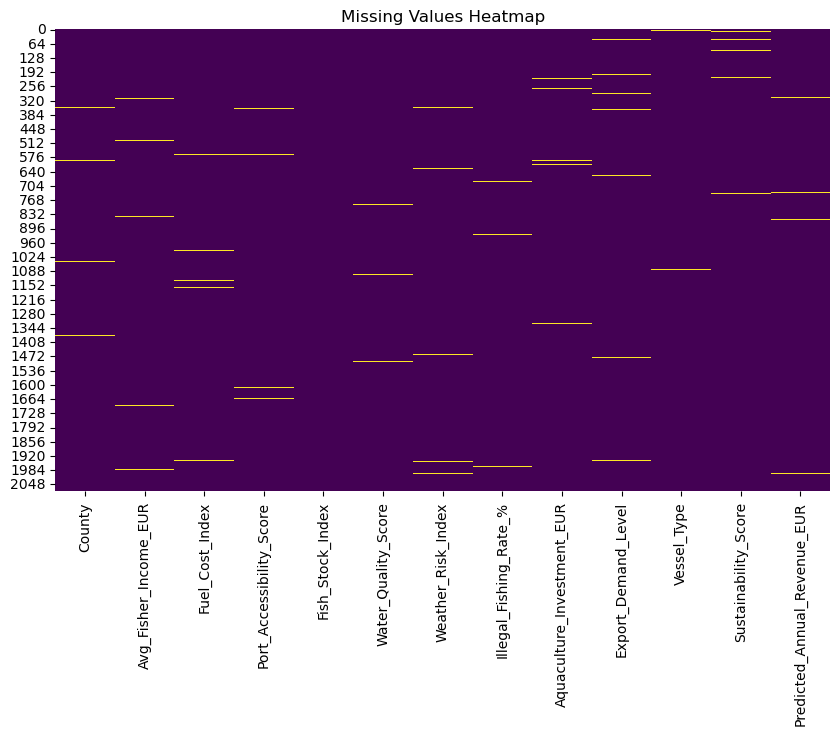

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()

In [22]:
duplicates = df.duplicated().sum()

print("Number of duplicated rows:", duplicates)

Number of duplicated rows: 0


In [23]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
Index(['Avg_Fisher_Income_EUR', 'Fuel_Cost_Index', 'Port_Accessibility_Score',
       'Fish_Stock_Index', 'Water_Quality_Score', 'Weather_Risk_Index',
       'Illegal_Fishing_Rate_%', 'Aquaculture_Investment_EUR',
       'Sustainability_Score', 'Predicted_Annual_Revenue_EUR'],
      dtype='object')

Categorical columns:
Index(['County', 'Export_Demand_Level', 'Vessel_Type'], dtype='object')


The variables were separated into numerical and categorical columns because each type of variable may require a different cleaning approach for numerical variables, missing values can be replaced with a statistical measure, such as the mean or median. For categorical variables, the mode is usually applied, as it represents the most frequent category.

In [24]:
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [25]:
df.isnull().sum()

County                          0
Avg_Fisher_Income_EUR           0
Fuel_Cost_Index                 0
Port_Accessibility_Score        0
Fish_Stock_Index                0
Water_Quality_Score             0
Weather_Risk_Index              0
Illegal_Fishing_Rate_%          0
Aquaculture_Investment_EUR      0
Export_Demand_Level             0
Vessel_Type                     0
Sustainability_Score            0
Predicted_Annual_Revenue_EUR    0
dtype: int64

Missing values were filled according to the variable type. Numerical columns were filled with the median, and categorical columns were filled with the mode.

In [26]:
df.duplicated().sum()

np.int64(0)

## Data Consistency Check

The numerical columns were checked to identify possible unusual values before continuing with the analysis.

In [27]:
df.describe()

,Avg_Fisher_Income_EUR,Fuel_Cost_Index,Port_Accessibility_Score,Fish_Stock_Index,Water_Quality_Score,Weather_Risk_Index,Illegal_Fishing_Rate_%,Aquaculture_Investment_EUR,Sustainability_Score,Predicted_Annual_Revenue_EUR
count,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000,2080.000000
mean,72512.495885,100.090630,5.969663,5.955197,7.007192,4.114043,4.913582,109865.901082,103.045053,174694.794279
std,11785.578768,14.819598,1.970067,1.933746,1.450075,1.887078,1.992639,22113.118342,22.243771,43269.945095
min,35298.260000,52.680000,1.000000,1.000000,2.100000,1.000000,0.000000,38247.500000,25.490000,28148.810000
25%,64910.860000,90.410000,4.630000,4.650000,6.030000,2.727500,3.580000,95611.100000,88.465000,146179.925000
50%,72646.920000,100.280000,6.000000,5.940000,7.030000,4.060000,4.850000,110054.900000,103.500000,176154.600000
75%,80255.117500,109.710000,7.310000,7.250000,7.990000,5.400000,6.300000,125139.440000,117.882500,204588.972500
max,107127.470000,145.030000,10.000000,10.000000,10.000000,10.000000,11.790000,170958.000000,172.740000,303843.800000


In [28]:
score_columns = [
    'Port_Accessibility_Score',
    'Fish_Stock_Index',
    'Water_Quality_Score',
    'Weather_Risk_Index'
]

for column in score_columns:
    print(column)
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())
    print()

Port_Accessibility_Score
Minimum: 1.0
Maximum: 10.0

Fish_Stock_Index
Minimum: 1.0
Maximum: 10.0

Water_Quality_Score
Minimum: 2.1
Maximum: 10.0

Weather_Risk_Index
Minimum: 1.0
Maximum: 10.0



The score based variables were checked to confirm whether their values were within the expected ranges

## Exploratory Data Analysis

Some visualisations were created to understand the main patterns in the dataset before applying statistical analysis and machine learning.

In [29]:
df['Export_Demand_Level'].value_counts()

Export_Demand_Level
Average    998
Low        554
High       528
Name: count, dtype: int64

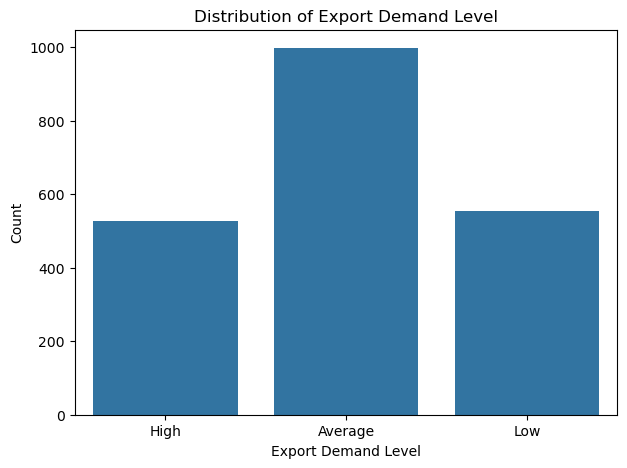

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Export_Demand_Level')

plt.title("Distribution of Export Demand Level")
plt.xlabel("Export Demand Level")
plt.ylabel("Count")

plt.show()

The export demand categories were checked to understand how the target variable for classification is distributed.

In [31]:
df['Vessel_Type'].value_counts()

Vessel_Type
Gillnetter     439
Small Boat     416
Trawler        414
Purse Seine    406
Longliner      405
Name: count, dtype: int64

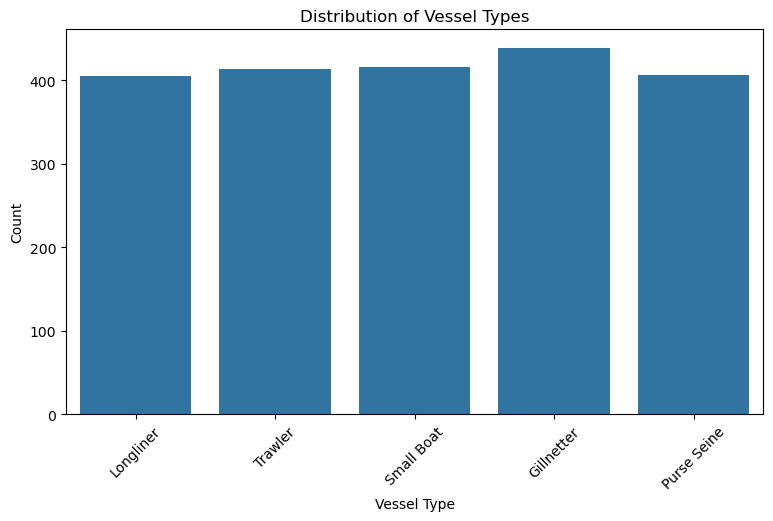

In [32]:
plt.figure(figsize=(9,5))

sns.countplot(data=df, x='Vessel_Type')

plt.title("Distribution of Vessel Types")
plt.xlabel("Vessel Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

Vessel type was explored because it is one of the operational variables that may influence fisheries performance.

The distribution of predicted annual revenue was explored to better understand the spread of the target variable used for regression analysis.

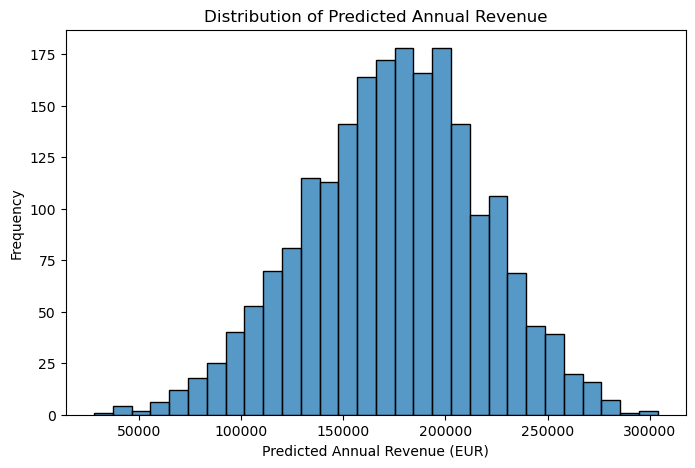

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df['Predicted_Annual_Revenue_EUR'], bins=30)

plt.title("Distribution of Predicted Annual Revenue")
plt.xlabel("Predicted Annual Revenue (EUR)")
plt.ylabel("Frequency")

plt.show()

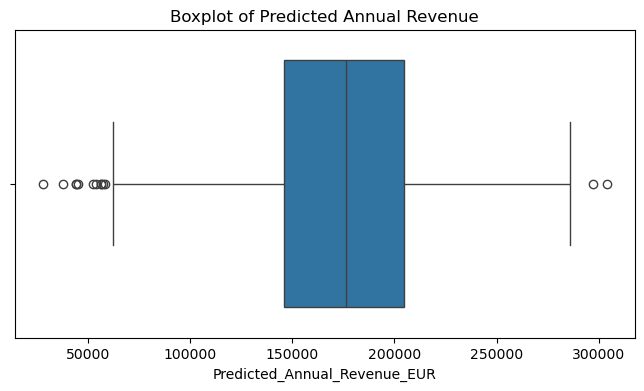

In [34]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Predicted_Annual_Revenue_EUR'])

plt.title("Boxplot of Predicted Annual Revenue")

plt.show()